In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [5]:
x_train, x_test = x_train[..., tf.newaxis], x_test[..., tf.newaxis]
# x_train = tf.expand_dims(x_train, axis=-1)

In [6]:
x_train.shape

(60000, 28, 28, 1)

In [7]:
model = tf.keras.models.Sequential([
		 tf.keras.layers.InputLayer(input_shape=[28, 28, 1]),
		tf.keras.layers.Conv2D(filters=16, kernel_size=5, strides=2, activation='relu'),
		 tf.keras.layers.MaxPooling2D((2,2)),
		tf.keras.layers.Conv2D(filters=32, kernel_size=5, activation='relu'),


	tf.keras.layers.Flatten(),
	tf.keras.layers.Dense(10, activation='softmax')
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 12, 12, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,538 (56.79 KB)

 Trainable params: 14,538 (56.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# [32, 10] [[0.0, 0.0, 0.1, 0.0, 0.1, 0.0, 0.1, 0.0, 0.1, 0.6], [0.0, 0.0, 0.1, 0.0, 0.1, 0.0, 0.1, 0.0, 0.1, 0.6], ...]

In [10]:
# [batch_size, number_of_classes]

In [11]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
y_train.shape

(60000,)

In [13]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

In [14]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8347 - loss: 0.5683 - val_accuracy: 0.9651 - val_loss: 0.1199
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9691 - loss: 0.1018 - val_accuracy: 0.9773 - val_loss: 0.0775
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9779 - loss: 0.0718 - val_accuracy: 0.9818 - val_loss: 0.0627
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9825 - loss: 0.0561 - val_accuracy: 0.9799 - val_loss: 0.0684
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0476 - val_accuracy: 0.9827 - val_loss: 0.0569


In [74]:
model.evaluate(x_test, tf.keras.utils.to_categorical(y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0514


[0.0393785759806633, 0.9878000020980835]

In [75]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [76]:
model.predict(x_test[:10]).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

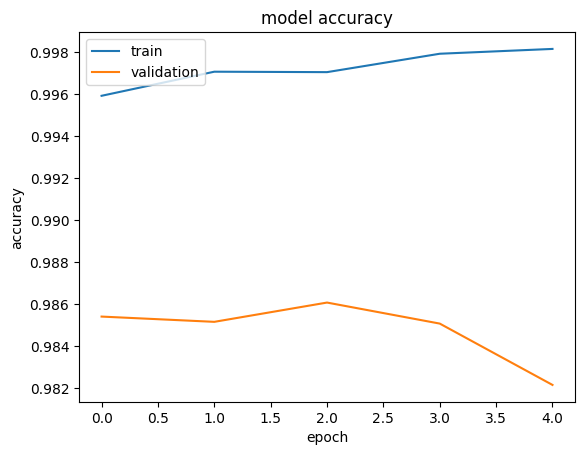

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [30]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

In [35]:
train_seq = tf.keras.utils.pad_sequences(x_train, maxlen=1000)
test_seq = tf.keras.utils.pad_sequences(x_test, maxlen=1000)

In [69]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Embedding(1000, 16))
model.add(tf.keras.layers.Conv1D(64, 3, activation='relu'))
model.add(tf.keras.layers.Conv1D(32, 3, activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['accuracy'])

In [70]:
model.fit(train_seq, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4991 - loss: 0.2500 - val_accuracy: 0.4938 - val_loss: 0.2500
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5025 - loss: 0.2500 - val_accuracy: 0.4938 - val_loss: 0.2500
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4960 - loss: 0.2500 - val_accuracy: 0.4938 - val_loss: 0.2500
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5027 - loss: 0.2500 - val_accuracy: 0.4938 - val_loss: 0.2500
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5074 - loss: 0.2500 - val_accuracy: 0.5062 - val_loss: 0.2500


In [52]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 1000, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (32, 998, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 31936)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 16)               │       510,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 1)                │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,585,733 (6.05 MB)

 Trainable params: 528,577 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,057,156 (4.03 MB)

In [ ]:
model.evaluate(test_seq, y_test)

In [ ]:
model.predict(test_seq[:10])